In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
plt.rc('xtick', labelsize=20) 
plt.rc('ytick', labelsize=20) 

In [3]:
def eV2au(eV: float):
    return 0.036749325871*eV

def nm2au(nm: float):
    return 18.897261339*nm

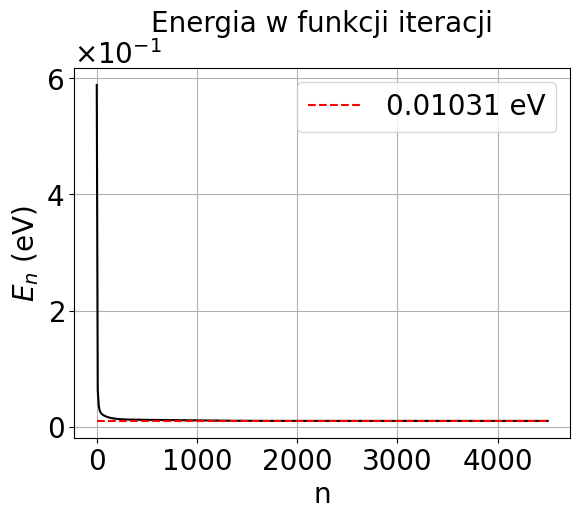

In [4]:
data1 = np.loadtxt('z1.dat')
length = np.size(data1)

############
co_ile = 10
############

iteracja = np.arange(0, length, co_ile);

plt.plot(iteracja, data1[::co_ile]/eV2au(1.0), color='k')
plt.plot(iteracja, data1[-1]*np.ones_like(iteracja)/eV2au(1.0), color='r',
        linestyle = '--', label = f'{data1[-1]/eV2au(1.0):.5f} eV')
plt.title("Energia w funkcji iteracji", fontsize = 20)
plt.xlabel('n', fontsize = 20)
plt.ylabel(r'$E_{n}$ (eV)', fontsize = 20)
plt.legend(fontsize= 20)
plt.grid(True)

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.show()

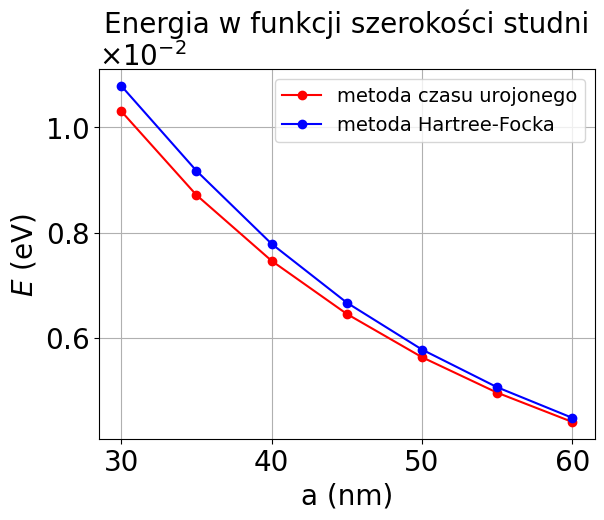

In [5]:
data2 = np.loadtxt('z2.dat')
data4 = np.loadtxt('z4.dat')
length2 = np.size(data2)
length4 = np.size(data4)
iteracja = np.arange(30, 61, 5)

plt.plot(iteracja, data2/eV2au(1.0), color='r',
    linestyle = '-', marker = 'o', label= 'metoda czasu urojonego')
plt.plot(iteracja, data4/eV2au(1.0), color='b',
    linestyle = '-', marker = 'o', label= 'metoda Hartree-Focka')

plt.title("Energia w funkcji szerokości studni", fontsize = 20)
plt.xlabel('a (nm)', fontsize = 20)
plt.ylabel(r'$E$ (eV)', fontsize = 20)
plt.legend(fontsize= 14)
plt.grid(True)

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.show()

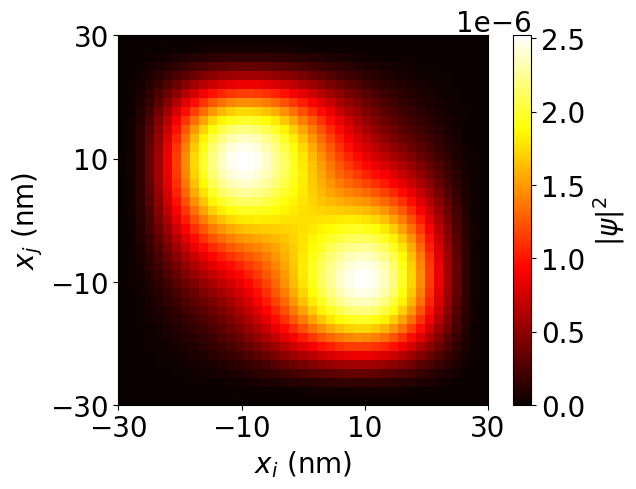

In [6]:
data_30 = np.loadtxt('z3_30.dat')
a = 30

plt.imshow(data_30[::-1]*data_30[::-1], cmap='hot', interpolation='nearest', extent=[-a, a, -a, a])
plt.gca().set_xticks(np.linspace(-a, a, data_30.shape[1]//10))
plt.gca().set_yticks(np.linspace(-a, a, data_30.shape[0]//10))
plt.xlabel(r'$x_i$ (nm)', fontsize=20)
plt.ylabel(r'$x_j$ (nm)', fontsize=20)
cbar = plt.colorbar(label=r'$|\psi|^2$')
cbar.ax.tick_params(labelsize=20)
cbar.set_label(r'$|\psi|^2$', fontsize=20)
plt.show()

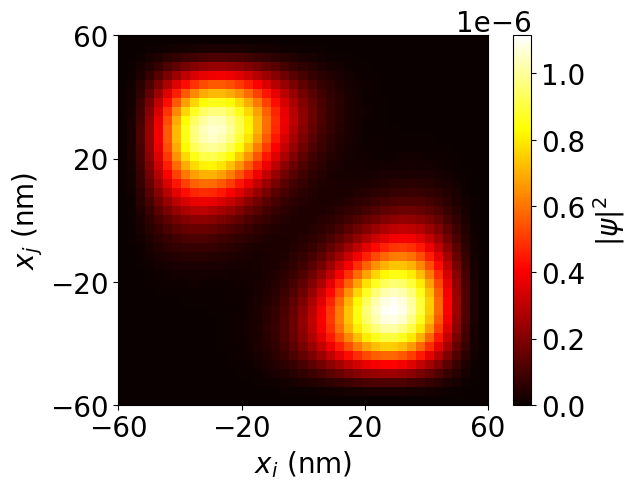

In [7]:
data_60 = np.loadtxt('z3_60.dat')
a = 60

plt.imshow(data_60[::-1]*data_60[::-1], cmap='hot', interpolation='nearest', extent=[-a, a, -a, a])
plt.gca().set_xticks(np.linspace(-a, a, data_60.shape[1]//10))
plt.gca().set_yticks(np.linspace(-a, a, data_60.shape[0]//10))
plt.xlabel(r'$x_i$ (nm)', fontsize=20)
plt.ylabel(r'$x_j$ (nm)', fontsize=20)
cbar = plt.colorbar(label=r'$|\psi|^2$')
cbar.ax.tick_params(labelsize=20)
cbar.set_label(r'$|\psi|^2$', fontsize=20)
plt.show()

Text(0.5, 0, '$x_i$ (nm)')

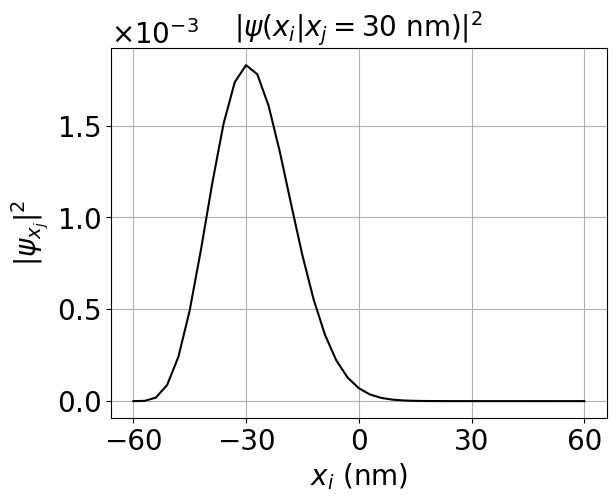

In [8]:
# p-stwo warunkowe:
# P(x|y=y_1) = P(x,y_1)/P(y_1)

def idx(x):
    return x/3 + 20

wf = data_60[::-1]

Py_1 = np.sum(data_60[int(idx(15)),:]*data_60[int(idx(15)),:])*120/40 # P(y_1) = Sdx P(x,y_1)
Pxy_1 = data_60[int(idx(30)),:]*data_60[int(idx(30)),:]
PxIy_1 = Pxy_1/Py_1

fig, ax = plt.subplots()
ax.plot(np.linspace(-60, 60, np.size(PxIy_1)), PxIy_1*PxIy_1, color = 'k')
ax.grid()
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
plt.title(r'$|\psi(x_i|x_j = 30$ nm$)|^2$', fontsize = 20)
ax.yaxis.set_major_formatter(formatter)
plt.xticks([-60, -30, 0, 30, 60])
plt.ylabel(r'$|\psi_{x_j}|^2$', fontsize=20)
plt.xlabel(r'$x_i$ (nm)', fontsize=20)

Text(0.5, 0, 'x (nm)')

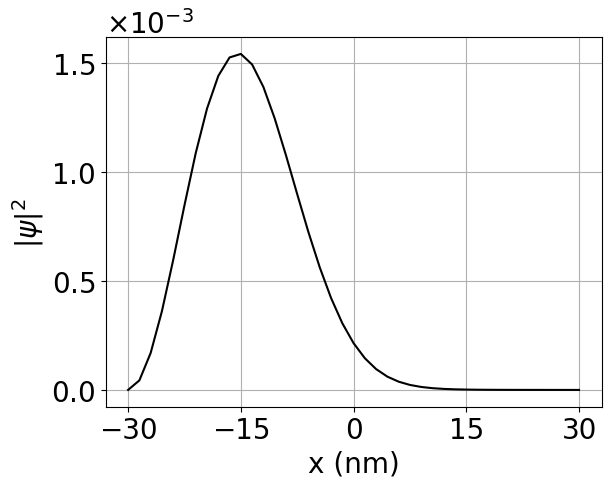

In [9]:
vec60 = np.loadtxt('30.dat')

fig, ax = plt.subplots()
ax.plot(np.linspace(-30, 30, np.size(vec60)), vec60*vec60, color = 'k')
ax.grid()
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
ax.yaxis.set_major_formatter(formatter)
plt.xticks([-30, -15, 0, 15, 30])
plt.ylabel(r'$|\psi|^2$', fontsize=20)
plt.xlabel('x (nm)', fontsize=20)